## Environment setup

### Configure your API keys

To pull Segment Anything 3 weights, you need a HuggingFace Access Token with approved access to the SAM 3 checkpoints.

- Request access to the SAM 3 checkpoints on the official [repo](https://github.com/facebookresearch/sam3).
- Open your HuggingFace Settings page. Click Access Tokens then New Token to generate a new token.
- Create a `.env` file in the project root with `HF_TOKEN=your_token_here`.


In [1]:
import os
import pathlib
import dotenv

# Ensure working directory is sam3-trials/ regardless of kernel state.
# Walk up from CWD until we find the notebook file.
_cwd = pathlib.Path.cwd()
for _p in [_cwd, *_cwd.parents]:
    if (_p / "how_to_segment_images_with_segment_anything_3.ipynb").exists():
        os.chdir(_p)
        break
print(f"Working directory: {os.getcwd()}")

PROJECT_ROOT = pathlib.Path.cwd().parent
dotenv.load_dotenv(PROJECT_ROOT / ".env")

print(os.environ.get("HF_TOKEN")[:3] + "******************")

Working directory: /Users/berkay.gok/Desktop/personal/cv-urban-accessibility-senior-project/sam3-trials
hf_******************


### Check hardware availability

Check which compute device is available (CUDA GPU, Apple MPS, or CPU).

In [2]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")


PyTorch version: 2.10.0
Torchvision version: 0.25.0
Using device: mps


### Install SAM 3 and extra dependencies

SAM 3 is installed as an editable package from the cloned repo in `sam3-trials/sam3/`.
Run the cell below if you haven't installed it yet. The `edt.py` module has been patched
to provide a CPU fallback (scipy) for the Triton-based Euclidean Distance Transform,
since Triton is CUDA-only and unavailable on macOS.

In [3]:
# Only run this cell once to install dependencies.
# sam3 is installed from the local clone at sam3-trials/sam3/
# The repo's edt.py and sam3_image_dataset.py have been patched for CPU compatibility.

# !pip install -e ../sam3-trials/sam3/    # (run from project root if needed)
# !pip install supervision jupyter_bbox_widget scipy pycocotools


## Load SAM3 Image Predictor

Load the SAM 3 image model. On CPU/MPS we use `bfloat16` autocast for reduced memory usage.

In [4]:
import torch

if DEVICE.type == "cuda":
    torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
else:
    torch.autocast(device_type="cpu", dtype=torch.bfloat16).__enter__()


In [5]:
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

model = build_sam3_image_model(device=str(DEVICE))
processor = Sam3Processor(model, confidence_threshold=0.3)


/Users/berkay.gok/Desktop/personal/cv-urban-accessibility-senior-project/sam3-trials/sam3/sam3/model/sam3_video_inference.py:799: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.bfloat16)
/Users/berkay.gok/Desktop/personal/cv-urban-accessibility-senior-project/sam3-trials/sam3/sam3/model/sam3_video_inference.py:907: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.bfloat16)


## Few utils to parse and visualize the result

In [6]:
import supervision as sv

def from_sam(sam_result: dict) -> sv.Detections:
    xyxy = sam_result["boxes"].to(torch.float32).cpu().numpy()
    confidence = sam_result["scores"].to(torch.float32).cpu().numpy()

    mask = sam_result["masks"].to(torch.bool)
    mask = mask.reshape(mask.shape[0], mask.shape[2], mask.shape[3]).cpu().numpy()

    return sv.Detections(
        xyxy=xyxy,
        confidence=confidence,
        mask=mask
    )

In [7]:
import supervision as sv
from PIL import Image
from typing import Optional


COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])


def annotate(image: Image.Image, detections: sv.Detections, label: Optional[str] = None) -> Image.Image:
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    mask_annotator = sv.MaskAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        opacity=0.6
    )
    box_annotator = sv.BoxAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        thickness=1
    )
    label_annotator = sv.LabelAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        text_scale=0.4,
        text_padding=5,
        text_color=sv.Color.BLACK,
        text_thickness=1
    )

    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(annotated_image, detections)
    annotated_image = box_annotator.annotate(annotated_image, detections)

    if label:
        labels = [
            f"{label} {confidence:.2f}"
            for confidence in detections.confidence
        ]
        annotated_image = label_annotator.annotate(annotated_image, detections, labels)

    return annotated_image

## SAM 3 text prompt

There are 10 taxi objects detected in the image.



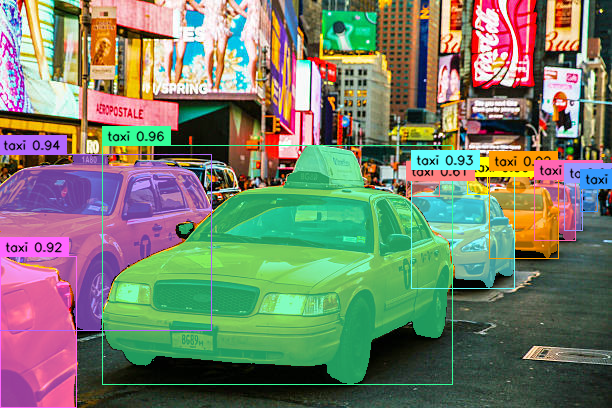

In [9]:
from PIL import Image
from IPython.display import display

PROMPT = "taxi"
IMAGE_PATH = 'images/istockphoto-518657226-612x612.jpg'

image = Image.open(IMAGE_PATH).convert("RGB")
inference_state = processor.set_image(image)
inference_state = processor.set_text_prompt(state=inference_state, prompt=PROMPT)

detections = from_sam(sam_result=inference_state)
detections = detections[detections.confidence > 0.5]

print(f"There are {len(detections)} {PROMPT} objects detected in the image.\n")
annotate(image, detections, label=PROMPT)

## SAM 3 box prompt

In [ ]:
import base64
from io import BytesIO
from PIL import Image

OBJECTS = ['positive', 'negative']

def encode_image_pillow(image: Image.Image) -> str:
    buffer = BytesIO()
    image.save(buffer, format="JPEG")
    image_bytes = buffer.getvalue()
    encoded = base64.b64encode(image_bytes).decode("utf-8")
    return "data:image/jpeg;base64," + encoded

When prompting SAM 3 with bounding boxes, the model expects boxes in the `xcycwh` format (`x_center`, `y_center`, `width`, `height`), and the coordinates must be normalized. The code below handles the conversion to this format.

In [ ]:
import numpy as np

def get_normalized_boxes(bboxes, label, resolution_wh):
    width, height = resolution_wh
    boxes = [
        [b["x"] + b["width"] / 2, b["y"] + b["height"] / 2, b["width"], b["height"]]
        for b in bboxes
        if b["label"] == label
    ]
    if not boxes:
        return np.empty((0, 4), dtype=np.float32)
    scale = np.array([width, height, width, height], dtype=np.float32).reshape(1,-1)
    return np.array(boxes, dtype=np.float32) / scale

In [ ]:
from PIL import Image
from jupyter_bbox_widget import BBoxWidget

image_path = 'images/birds.jpg'
image = Image.open(image_path).convert("RGB")

widget = BBoxWidget(classes=OBJECTS)
widget.image = encode_image_pillow(image)
widget

In [ ]:
xyxy_positive = get_normalized_boxes(widget.bboxes, "positive", image.size)
xyxy_negatives = get_normalized_boxes(widget.bboxes, "negative", image.size)

inference_state = processor.set_image(image)
processor.reset_all_prompts(inference_state)

for box in xyxy_positive:
    inference_state = processor.add_geometric_prompt(state=inference_state, box=box, label=True)
for box in xyxy_negatives:
    inference_state = processor.add_geometric_prompt(state=inference_state, box=box, label=False)

detections = from_sam(sam_result=inference_state)
detections = detections[detections.confidence > 0.5]
annotate(image, detections)

In [ ]:
from PIL import Image
from jupyter_bbox_widget import BBoxWidget

image_path = 'images/pills.jpg'
image = Image.open(image_path).convert("RGB")

widget = BBoxWidget(classes=OBJECTS)
widget.image = encode_image_pillow(image)
widget

In [ ]:
xyxy_positive = get_normalized_boxes(widget.bboxes, "positive", image.size)
xyxy_negatives = get_normalized_boxes(widget.bboxes, "negative", image.size)

inference_state = processor.set_image(image)
processor.reset_all_prompts(inference_state)

for box in xyxy_positive:
    inference_state = processor.add_geometric_prompt(state=inference_state, box=box, label=True)
for box in xyxy_negatives:
    inference_state = processor.add_geometric_prompt(state=inference_state, box=box, label=False)

detections = from_sam(sam_result=inference_state)
detections = detections[detections.confidence > 0.5]
annotate(image, detections)

## Load SAM 3 Interactive Image Predictor

Segment Anything Model 3 (SAM 3) predicts object masks given prompts that indicate the desired object. The model first converts the image into an image embedding that allows high quality masks to be efficiently produced from a prompt.

`SAM3InteractiveImagePredictor.predict` takes the following arguments:

- `point_coords` - `[np.ndarray or None]` - a `Nx2` array of point prompts to the model. Each point is in `(X,Y)` in pixels.
- `point_labels` - `[np.ndarray or None]` - a length `N` array of labels for the
point prompts. `1` indicates a foreground point and `0` indicates a
background point.
- `box` - `[np.ndarray or None]` - a length `4` array given a box prompt to the
model, in `[x_min, y_min, x_max, y_max]` format.
- `mask_input` - `[np.ndarray]` - a low resolution mask input to the model, typically coming from a previous prediction iteration. Has form `1xHxW`, where
for SAM, `H=W=256`.
- `multimask_output` - `[bool]` - if true, the model will return three masks.
For ambiguous input prompts (such as a single click), this will often
produce better masks than a single prediction. If only a single
mask is needed, the model's predicted quality score can be used
to select the best mask. For non-ambiguous prompts, such as multiple
input prompts, `multimask_output=False` can give better results.
- `return_logits` - `[bool]` - if true, returns un-thresholded masks logits
instead of a binary mask.
- `normalize_coords` - `[bool]` - if true, the point coordinates will be normalized to the range `[0,1]` and point_coords is expected to be wrt. image dimensions.

In [ ]:
model = build_sam3_image_model(enable_inst_interactivity=True, device=str(DEVICE))
processor = Sam3Processor(model, confidence_threshold=0.3)


In [ ]:
def from_sam_interactive(sam_result: tuple[np.ndarray, np.ndarray]) -> sv.Detections:
    masks, scores = sam_result

    if masks.shape[0] != 1:
        masks = np.squeeze(masks)

    return sv.Detections(
        xyxy=sv.mask_to_xyxy(masks=masks),
        mask=masks.astype(bool),
        confidence=np.squeeze(scores)
    )

In [ ]:
import numpy as np

def get_xy_points(boxes, label):
    points = [
        [b["x"] + b["width"] / 2, b["y"] + b["height"] / 2]
        for b in boxes
        if b["label"] == label
    ]
    if not points:
        return np.empty((0, 2), dtype=np.float32)
    return np.array(points, dtype=np.float32)


def get_xyxy_boxes(boxes, label):
    boxes = [
        [b["x"], b["y"], b["x"] + b["width"], b["y"] + b["height"]]
        for b in boxes
        if b["label"] == label
    ]
    if not boxes:
        return np.empty((0, 4), dtype=np.float32)
    return np.array(boxes, dtype=np.float32)

## Interactive SAM 3 box prompt

In [ ]:
from PIL import Image
from jupyter_bbox_widget import BBoxWidget

image_path = 'images/dog-2.jpeg'
image = Image.open(image_path).convert("RGB")

widget = BBoxWidget(classes=OBJECTS)
widget.image = encode_image_pillow(image)
widget

In [ ]:
default_box = [
    {'x': 172, 'y': 830, 'width': 96, 'height': 179, 'label': 'positive'},
    {'x': 162, 'y': 1044, 'width': 282, 'height': 165, 'label': 'positive'},
    {'x': 353, 'y': 723, 'width': 34, 'height': 162, 'label': 'positive'},
    {'x': 468, 'y': 888, 'width': 173, 'height': 247, 'label': 'positive'}
]

boxes = widget.bboxes if widget.bboxes else default_box
boxes = get_xyxy_boxes(boxes=boxes, label='positive')

inference_state = processor.set_image(image)

masks, scores, logits = model.predict_inst(
    inference_state,
    box=boxes,
    multimask_output=False
)

detections = from_sam_interactive((masks, scores))

box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)

source_image = box_annotator.annotate(scene=image.copy(), detections=detections)
result_image = mask_annotator.annotate(scene=image.copy(), detections=detections)

sv.plot_images_grid(
    images=[source_image, result_image],
    grid_size=(1, 2),
    titles=['source image', 'result image']
)

## Interactive SAM 3 point prompt

In [ ]:
from PIL import Image
from jupyter_bbox_widget import BBoxWidget

image_path = 'images/dog-2.jpeg'
image = Image.open(image_path).convert("RGB")

widget = BBoxWidget(classes=OBJECTS)
widget.image = encode_image_pillow(image)
widget

In [ ]:
default_box = [
    {'x': 84, 'y': 1034, 'width': 0, 'height': 0, 'label': 'positive'},
    {'x': 705, 'y': 1252, 'width': 0, 'height': 0, 'label': 'positive'},
    {'x': 704, 'y': 1015, 'width': 0, 'height': 0, 'label': 'positive'},
    {'x': 427, 'y': 1059, 'width': 0, 'height': 0, 'label': 'positive'},
    {'x': 138, 'y': 1237, 'width': 0, 'height': 0, 'label': 'positive'},
    {'x': 274, 'y': 1143, 'width': 0, 'height': 0, 'label': 'negative'},
    {'x': 463, 'y': 1117, 'width': 0, 'height': 0, 'label': 'negative'},
    {'x': 652, 'y': 1145, 'width': 0, 'height': 0, 'label': 'negative'},
    {'x': 196, 'y': 982, 'width': 0, 'height': 0, 'label': 'negative'}
]

boxes = widget.bboxes if widget.bboxes else default_box
points_positive = get_xy_points(widget.bboxes, "positive")
points_negatives = get_xy_points(widget.bboxes, "negative")

input_point = np.vstack((points_positive, points_negatives))
input_label = np.array([1] * len(points_positive) + [0] * len(points_negatives))

inference_state = processor.set_image(image)
masks, scores, logits = model.predict_inst(
    inference_state,
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

sv.plot_images_grid(
    images=masks,
    titles=[f"score: {score:.2f}" for score in scores],
    grid_size=(1, 3),
    size=(12, 12)
)

<div align="center">
  <p>
    Looking for more tutorials or have questions?
    Check out our <a href="https://github.com/roboflow/notebooks">GitHub repo</a> for more notebooks,
    or visit our <a href="https://discord.gg/GbfgXGJ8Bk">discord</a>.
  </p>
  
  <p>
    <strong>If you found this helpful, please consider giving us a ⭐
    <a href="https://github.com/roboflow/notebooks">on GitHub</a>!</strong>
  </p>

</div>